In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
df = pd.read_excel('/Users/milad/Desktop/Rulex/Final Raw.xlsx')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [8]:
print(df.head())
# print(df.describe())
# print(df.info)
# print(df.shape)
# print(df.value_counts())
print(df.columns.tolist())


   "matchId"  "homeTeamId"  "awayTeamId"  "result"  "assists_home"  \
0    1694390          4418         11944  home_win               2   
1    1694391          8731          6697  away_win               0   
2    1694392         11944          6697      draw               0   
3    1694393          4418          8731  home_win               2   
4    1694394          6697          4418      draw               0   

   "assists_away"  "simple_passes_home_pct"  "simple_passes_away_pct"  \
0               0                 71.351351                 28.648649   
1               1                 39.295775                 60.704225   
2               1                 25.140713                 74.859287   
3               0                 62.748092                 37.251908   
4               0                 61.919505                 38.080495   

   "high_passes_home_pct"  "high_passes_away_pct"  ...  \
0               31.147541               68.852459  ...   
1               56.06060

In [9]:
cols_to_drop = ['"matchId"', '"homeTeamId"', '"awayTeamId"']
X = df.drop(columns=['"result"'] + cols_to_drop)
y = df['"result"']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [14]:
clf = DecisionTreeClassifier( random_state=42, max_depth=10, class_weight='balanced', min_samples_leaf=5)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [15]:
print(clf.score(X_test, y_test))
print(clf.score(X_train, y_train))
print(classification_report(y_train, clf.predict(X_train)))
print(classification_report(y_test, clf.predict(X_test)))

0.4717948717948718
0.7697594501718213
              precision    recall  f1-score   support

    away_win       0.78      0.81      0.80       533
        draw       0.63      0.86      0.73       429
    home_win       0.90      0.69      0.78       784

    accuracy                           0.77      1746
   macro avg       0.77      0.79      0.77      1746
weighted avg       0.80      0.77      0.77      1746

              precision    recall  f1-score   support

    away_win       0.42      0.47      0.45        59
        draw       0.34      0.50      0.40        48
    home_win       0.69      0.45      0.55        88

    accuracy                           0.47       195
   macro avg       0.48      0.48      0.47       195
weighted avg       0.52      0.47      0.48       195



In [16]:
#Feature Importance
importance = pd.Series(clf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

"crosses_att_away"              0.081416
"crosses_def_home"              0.072569
"high_passes_def_home"          0.066216
"simple_passes_att_home_pct"    0.047945
"high_passes_att_away"          0.047306
                                  ...   
"assists_away"                  0.000000
"smart_passes_att_home"         0.000000
"smart_passes_mid_home"         0.000000
"hand_fouls_home_pct"           0.000000
"assists_home"                  0.000000
Length: 64, dtype: float64


In [18]:
importance

"assists_home"              0.000000
"assists_away"              0.000000
"simple_passes_home_pct"    0.009538
"simple_passes_away_pct"    0.033873
"high_passes_home_pct"      0.009342
                              ...   
"throw_ins_att_away_pct"    0.022795
overall_home                0.024181
overall_away                0.003204
xg_overall_home             0.045841
xg_overall_away             0.039556
Length: 64, dtype: float64

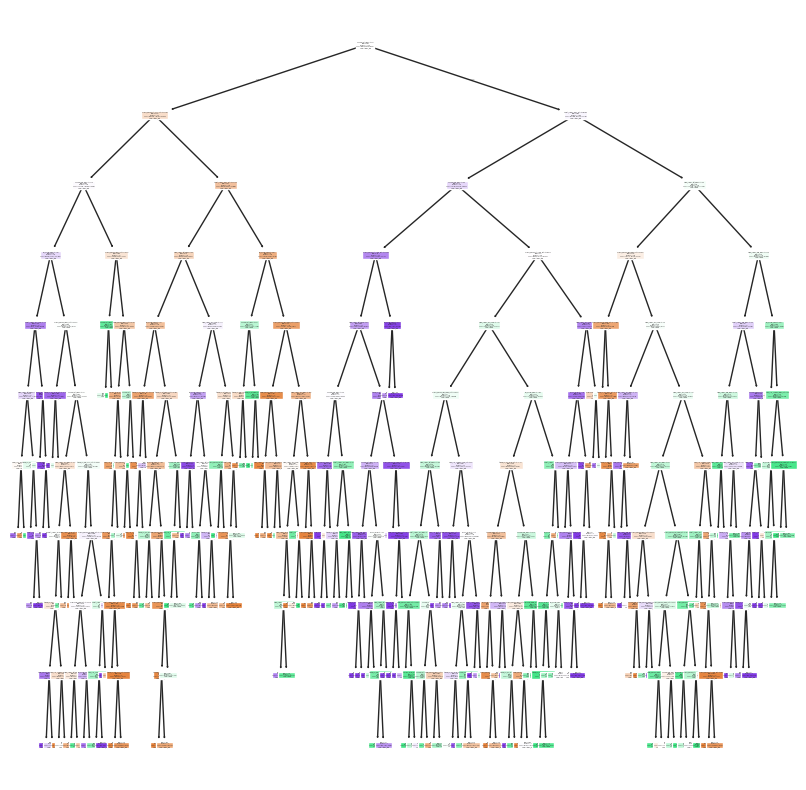

In [17]:
plt.figure(figsize = (10,10))
plot_tree(clf, feature_names = X.columns, class_names=clf.classes_, filled=True)
plt.show()